In [1]:
!pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 330.3 kB/s eta 0:00:01
     ---------------------- --------------- 30.7/52.8 kB 445.2 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 390.8 kB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------- ------------------- 61.4/119.8 kB ? eta -:--:--
     -------------------------------------- 119.8/119.8 kB 2.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.1/8.1 MB 2.8 MB/s eta 0:00:03
    --------------------------------------- 0.2/8.1 MB 3.0 MB/s eta 0:00:03
   - -------------------------------------- 0.3/8.1 MB 2.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/8.1 MB 2.8 MB/s eta 0:00:03
   --- ------------

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load cleaned data
hourly = pd.read_csv("../data/clean/hourly_clean.csv")
qh = pd.read_csv("../data/clean/qh_clean.csv")

In [2]:
hourly["timestamp"] = pd.to_datetime(hourly["timestamp"])
qh["timestamp"] = pd.to_datetime(qh["timestamp"])

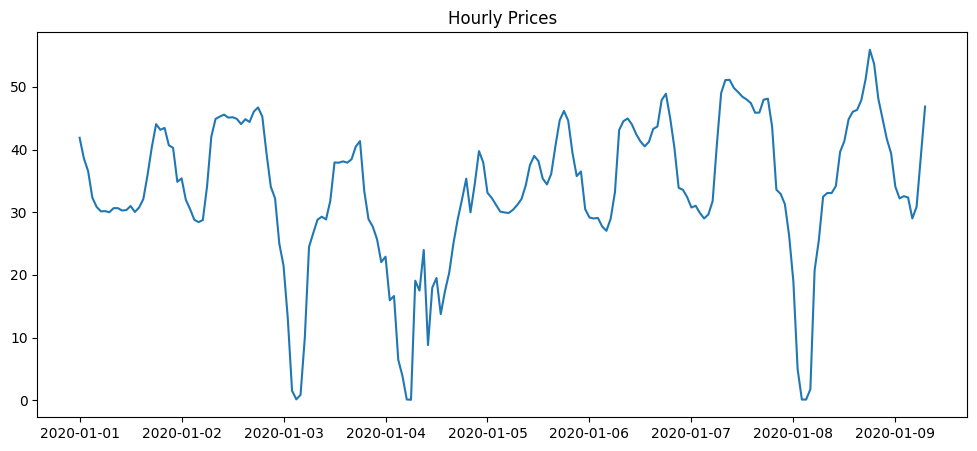

In [3]:
plt.figure(figsize=(12,5))
plt.plot(hourly["timestamp"][:200], hourly["price"][:200])
plt.title("Hourly Prices")
plt.show()

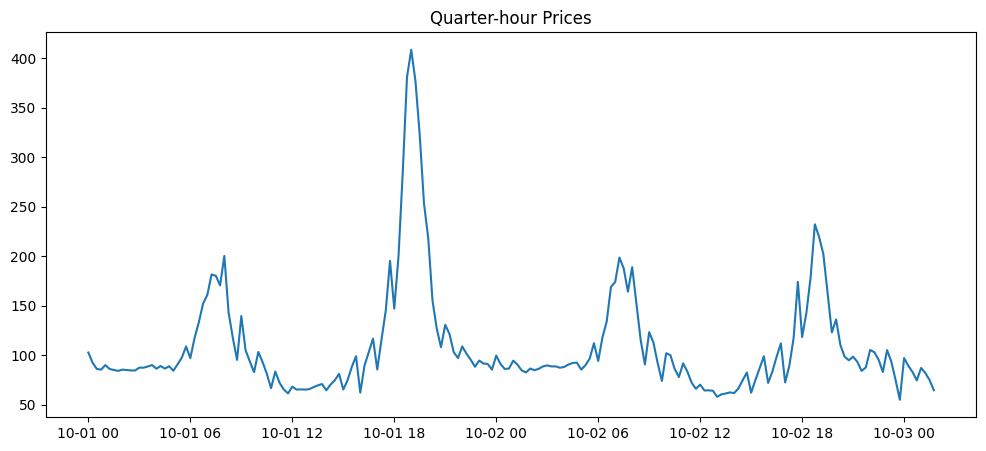

In [4]:
plt.figure(figsize=(12,5))
plt.plot(qh["timestamp"][:200], qh["price"][:200])
plt.title("Quarter-hour Prices")
plt.show()

In [5]:
!pip install statsmodels

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     -------------------------- ------------- 41.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB 1.3 MB/s eta 0:00:08
   ---------------------------------------- 0.1/9.6 MB 1.1 MB/s eta 0:00:10
    --------------------------------------- 0.1/9.6 MB 1.2 MB/s eta 0:00:08
    --------------------------------------- 0.2/9.6 MB 1.1 MB/s eta 0:00:09
   - -------------------------------------- 0.3/9.6 MB 1.5 MB/s eta 0:00:07
   - -------------------------------------- 0.3/9.6 MB 1.5 MB/s eta 0:00:07
   - -------------------------------------- 0.5/9.6 MB 1.3 MB/s eta 0:00:07
   - -------------------------------------- 0.5/9.6 MB 1.4 MB/s eta 0:00:07
   - ---------------------

In [7]:
### ---ARIMA Method

In [4]:
import pandas as pd

# load data again
hourly = pd.read_csv("../data/clean/hourly_clean.csv")

# convert time (always do this)
hourly["timestamp"] = pd.to_datetime(hourly["timestamp"])

hourly.head()

,timestamp,price
0,2020-01-01 00:00:00,41.88
1,2020-01-01 01:00:00,38.60
2,2020-01-01 02:00:00,36.55
3,2020-01-01 03:00:00,32.32
4,2020-01-01 04:00:00,30.85


In [5]:
from statsmodels.tsa.arima.model import ARIMA

series = hourly["price"][:500]

model = ARIMA(series, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=50)

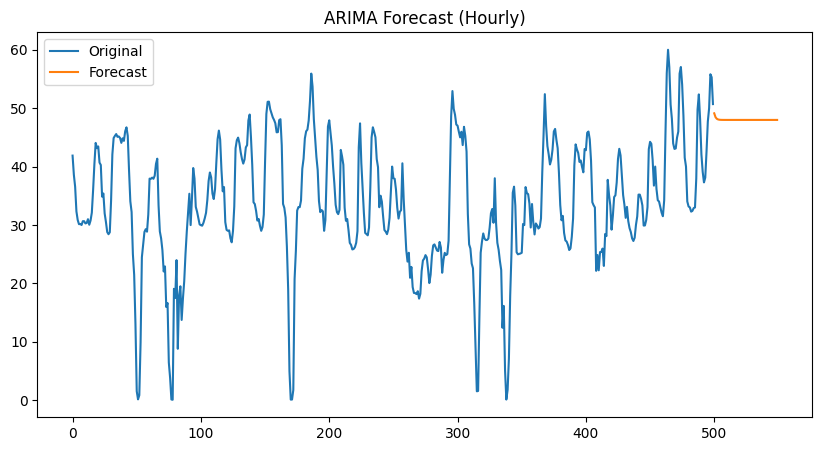

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(series, label="Original")
plt.plot(range(len(series), len(series)+50), forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast (Hourly)")
plt.show()

In [9]:
import pandas as pd

# load QH data
qh = pd.read_csv("../data/clean/qh_clean.csv")

# convert timestamp
qh["timestamp"] = pd.to_datetime(qh["timestamp"])

qh.head()

,timestamp,price
0,2025-10-01 00:00:00,102.60
1,2025-10-01 00:15:00,92.24
2,2025-10-01 00:30:00,86.03
3,2025-10-01 00:45:00,85.39
4,2025-10-01 01:00:00,89.99


In [10]:
from statsmodels.tsa.arima.model import ARIMA

series_qh = qh["price"][:500]

model_qh = ARIMA(series_qh, order=(1,1,1))
model_fit_qh = model_qh.fit()

forecast_qh = model_fit_qh.forecast(steps=50)

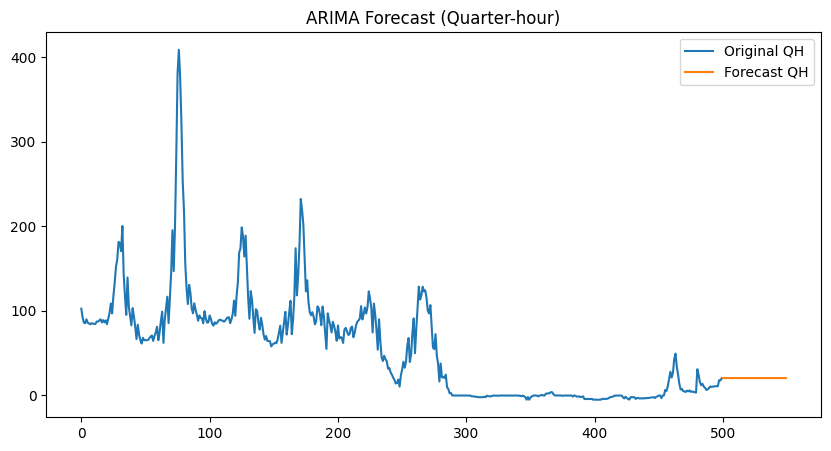

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(series_qh, label="Original QH")
plt.plot(range(len(series_qh), len(series_qh)+50), forecast_qh, label="Forecast QH")
plt.legend()
plt.title("ARIMA Forecast (Quarter-hour)")
plt.show()

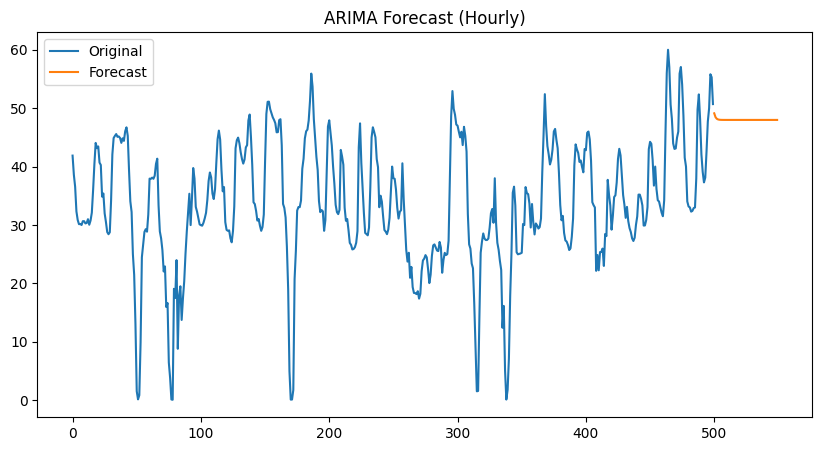

In [12]:
plt.figure(figsize=(10,5))
plt.plot(series, label="Original")
plt.plot(range(len(series), len(series)+50), forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast (Hourly)")
plt.savefig("../results/arima_hourly.png", dpi=300, bbox_inches="tight")
plt.show()

# A baseline ARIMA(1,1,1) model was applied to hourly and quarter-hourly electricity price data. The model produced relatively smooth forecasts and failed to capture the sharp fluctuations and extreme spikes observed in the data. This limitation was more pronounced in the quarter-hourly series, where increased temporal resolution revealed higher volatility and intra-hour variability.